Name:Shlok Nikam


Class:CSE-AI (D)

Batch: 2

PRN: 12414145

Roll no. 41

Assignment: 6

Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following: a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression modeling c. Multiple Regression analysis d. Also compare the results of the above analysis for the two data sets. Dataset link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

Loading dataset

In [ ]:
df = pd.read_csv("diabetes.csv")

print("Pima Dataset Shape:", df.shape)
print(df.head())


Pima Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target

print("Sklearn Diabetes Shape:", sklearn_df.shape)
print(sklearn_df.head())


Sklearn Diabetes Shape: (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Checking and handling missing values

In [ ]:
print(df.isnull().sum())
df.fillna(df.median(), inplace=True)


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Identifying outliers

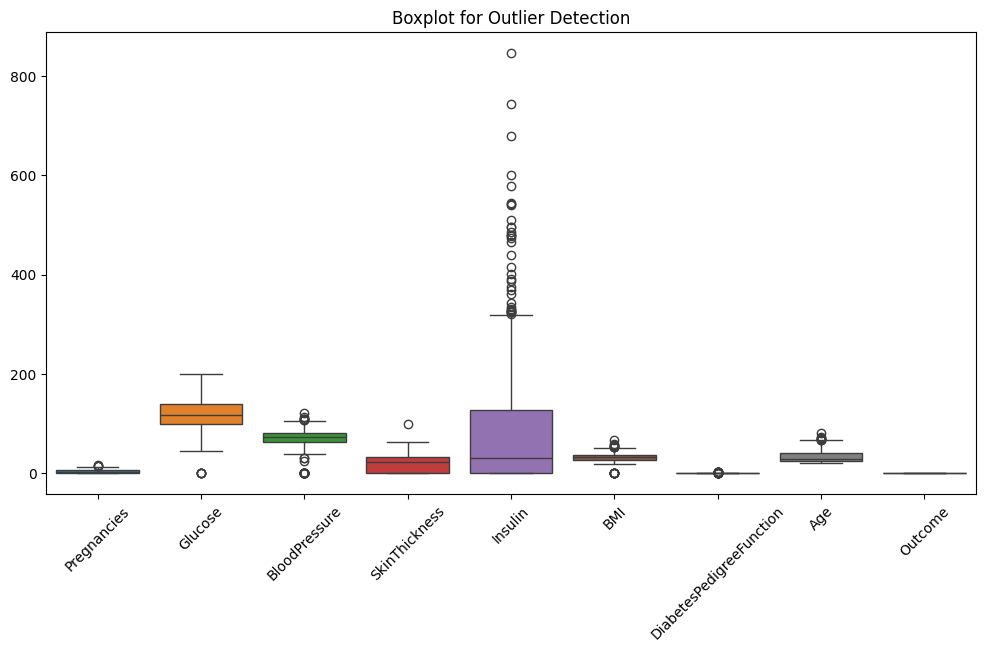

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()


Handling Outliers

In [ ]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                 (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Before:", df.shape)
print("After:", df_clean.shape)


Before: (768, 9)
After: (639, 9)


Finding correlation

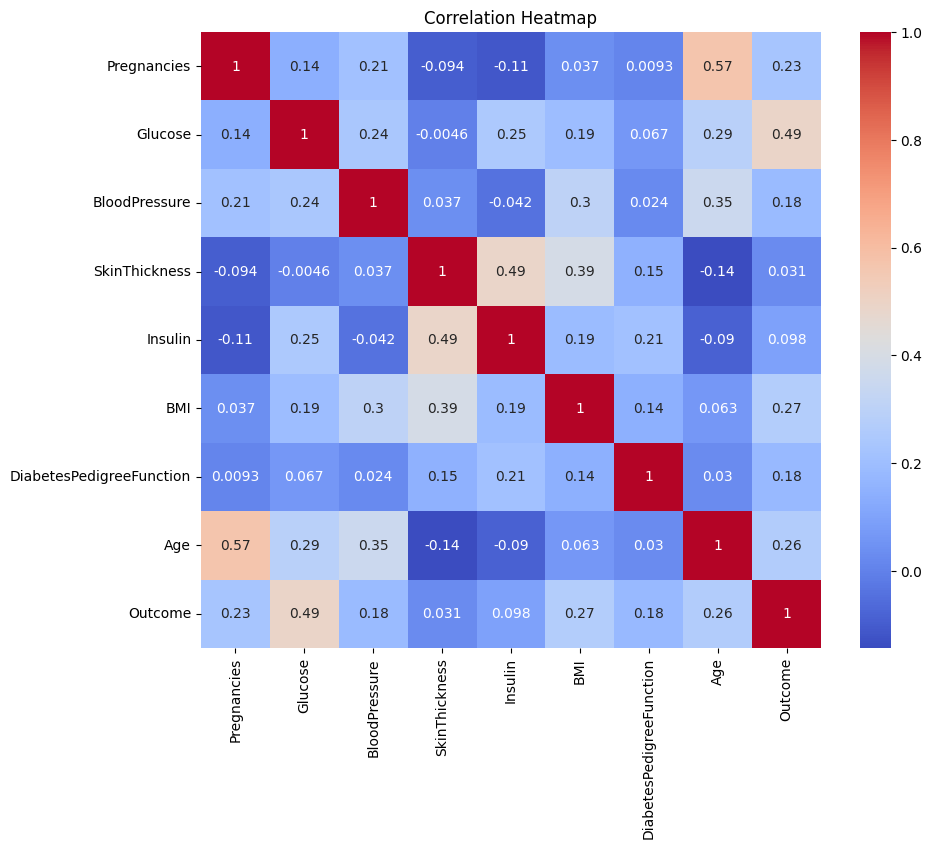

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



Univariate Analysis

We compute:

Frequency

Mean

Median

Mode

Variance

Standard Deviation

Skewness

Kurtosis

In [ ]:
def univariate_analysis(df):
    result = pd.DataFrame({
        "Mean": df.mean(),
        "Median": df.median(),
        "Mode": df.mode().iloc[0],
        "Variance": df.var(),
        "Std Dev": df.std(),
        "Skewness": df.skew(),
        "Kurtosis": df.kurt()
    })
    return result
    print(df.skew())


In [ ]:
print("Univariate Analysis - Pima Dataset")
print(univariate_analysis(df))

print("\nUnivariate Analysis - Sklearn Diabetes Dataset")
print(univariate_analysis(sklearn_df))

Univariate Analysis - Pima Dataset
                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                             Std Dev  Skewness  Kurtosis  
Pregnancies                 3.369578  0.901674  0.159220  
Glucose                    31.972618  0.173754  0.640780  
BloodPressure              19.355807 -1.843608  5.180157  
SkinThic

calculates the skewness of each numeric column

In [ ]:
skew_df = pd.DataFrame({
    "Skewness": df.skew()
}).sort_values(by="Skewness", ascending=False)

print(skew_df)


                          Skewness
Insulin                   2.272251
DiabetesPedigreeFunction  1.919911
Age                       1.129597
Pregnancies               0.901674
Outcome                   0.635017
Glucose                   0.173754
SkinThickness             0.109372
BMI                      -0.428982
BloodPressure            -1.843608


Frequency Distribution

In [ ]:
print("Frequency of Outcome in Pima Dataset:")
print(df['Outcome'].value_counts())


Frequency of Outcome in Pima Dataset:
Outcome
0    500
1    268
Name: count, dtype: int64


Linear regression (skinThinkness vs Insulin)

In [ ]:
corr = df_clean.corr()["Insulin"].sort_values(ascending=False)
print(corr)


Insulin                     1.000000
SkinThickness               0.487566
Glucose                     0.248225
DiabetesPedigreeFunction    0.213191
BMI                         0.188635
Outcome                     0.097746
BloodPressure              -0.041513
Age                        -0.089535
Pregnancies                -0.114510
Name: Insulin, dtype: float64


In [ ]:
X = df_clean[["SkinThickness"]]
y = df_clean["Insulin"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 50.836027149928434
MSE: 4546.704382146672
RMSE: 67.42925464623401
R² Score: 0.23866534054581812


Graph for linear regression

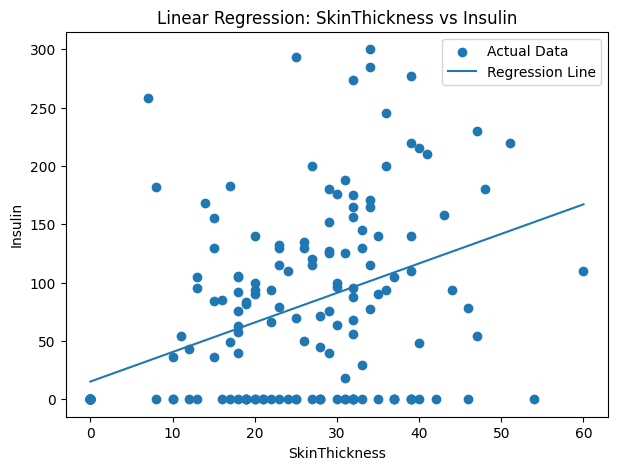

In [ ]:
X_test_np = X_test.values.reshape(-1, 1)
y_test_np = y_test.values

sorted_idx = np.argsort(X_test_np[:, 0])
X_sorted = X_test_np[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(7, 5))
plt.scatter(X_test_np, y_test_np, label="Actual Data")
plt.plot(X_sorted, y_pred_sorted, label="Regression Line")
plt.xlabel("SkinThickness")
plt.ylabel("Insulin")
plt.title("Linear Regression: SkinThickness vs Insulin")
plt.legend()
plt.show()



Graph for actual vs predicted values

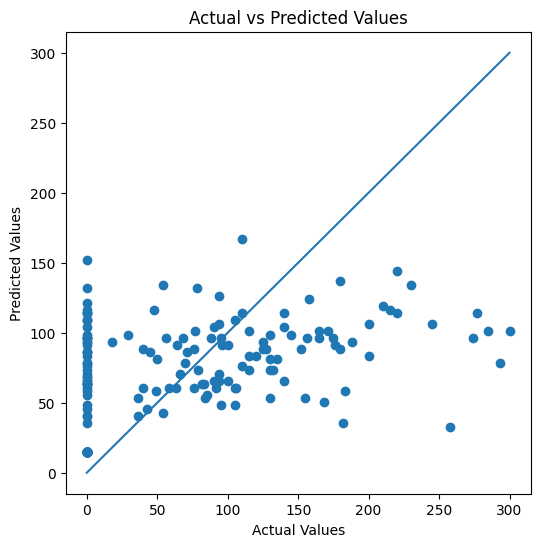

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

This computes the error for each data point

Residual = Actual value - Predicted value

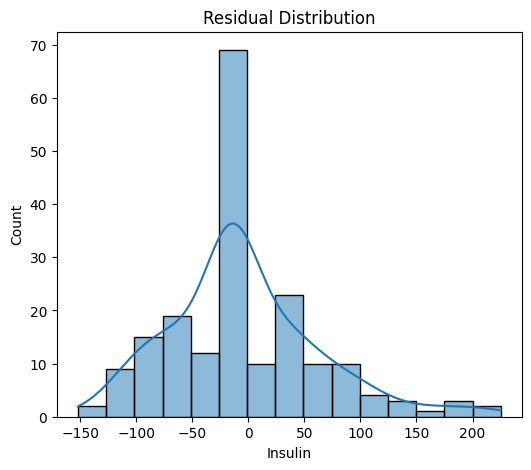

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [ ]:
new_data = pd.DataFrame({
    feature: [X[feature].mean()] for feature in X.columns
})

prediction = model.predict(new_data)
print("Predicted Value:", prediction)


Predicted Value: [67.18998743]


Linear Regression (bmi vs target)

In [ ]:
X = sklearn_df[['bmi']]
y = sklearn_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print("Linear Regression Results (Sklearn Dataset)")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Linear Regression Results (Sklearn Dataset)
Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 Score: 0.2803417492440603
MSE: 3884.936720961032


Logistic Regression

In [ ]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)

Y_pred = log_model.predict(X_test)

confusion matrix

In [ ]:
print(confusion_matrix(Y_test, Y_pred))

[[120  31]
 [ 30  50]]


Accuracy


In [ ]:
print("Logistic Regression Results (Pima Dataset)")
print("Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Results (Pima Dataset)
Accuracy: 0.7359307359307359


Logistic curve

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


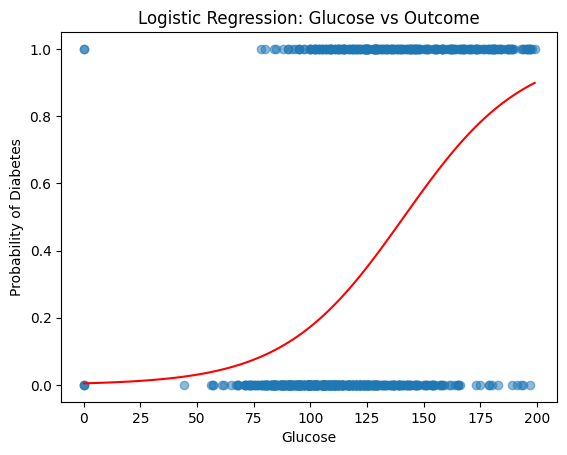

In [ ]:
X_glucose = df[['Glucose']]
Y_glucose = df['Outcome']

log_glucose = LogisticRegression()
log_glucose.fit(X_glucose, Y_glucose)

X_values = np.linspace(df['Glucose'].min(), df['Glucose'].max(), 100).reshape(-1,1)
Y_prob = log_glucose.predict_proba(X_values)[:,1]

plt.scatter(df['Glucose'], df['Outcome'], alpha=0.5)
plt.plot(X_values, Y_prob, color='red')
plt.xlabel("Glucose")
plt.ylabel("Probability of Diabetes")
plt.title("Logistic Regression: Glucose vs Outcome")
plt.show()

Multiple Regression Analysis

In [ ]:
X = sklearn_df.drop(columns=['target'])
y = sklearn_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

multi_lin = LinearRegression()
multi_lin.fit(X_train, y_train)

y_pred = multi_lin.predict(X_test)

print("Multiple Linear Regression (Sklearn Dataset)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Multiple Linear Regression (Sklearn Dataset)
R2 Score: 0.4772897164322617
MSE: 2821.750981001311


Multiple Logistic Regression

In [ ]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

multi_log = LogisticRegression(max_iter=2000)
multi_log.fit(X_train, y_train)

y_pred = multi_log.predict(X_test)

print("Multiple Logistic Regression (Pima Dataset)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Multiple Logistic Regression (Pima Dataset)
Accuracy: 0.7359307359307359
Confusion Matrix:
 [[120  31]
 [ 30  50]]


In [ ]:
print("\n================ DATASET COMPARISON ================")
print("""
The UCI and Kaggle Pima Indians Diabetes datasets are identical.
Both contain:
- 768 rows
- 8 input features
- 1 target variable (Outcome)

Hence statistical results, regression outputs, and accuracy values remain same
unless preprocessing methods differ.
""")


================ DATASET COMPARISON ================

The UCI and Kaggle Pima Indians Diabetes datasets are identical.
Both contain:
- 768 rows
- 8 input features
- 1 target variable (Outcome)

Hence statistical results, regression outputs, and accuracy values remain same
unless preprocessing methods differ.

